<a href="https://colab.research.google.com/github/JeremySamosir/Proyek-SisRec-07/blob/main/Hasil_Evaluasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

In [4]:
pip install openpyxl

In [ ]:
# df = pd.read_excel("/content/drive/MyDrive/SEM 7/SysRec/Data Proyek/Table_Jawaban.xlsx")

In [6]:
df = pd.read_excel("/content/drive/MyDrive/Kuliah/7/SISREK/Proyek/Data/Table_Jawaban.xlsx")

In [7]:
# --- Membuat DataFrame untuk ChatGPT ---
chatgpt_df = pd.DataFrame({
    "question": df["Prompt"],
    "answer": df["ChatGpt Output"],
    "ground_truth": df["Ground Truth"],
    "model": "ChatGPT"
})

In [8]:
# --- Membuat DataFrame untuk Gemini ---
gemini_df = pd.DataFrame({
    "question": df["Prompt"],
    "answer": df["Gemini Output"],
    "ground_truth": df["Ground Truth"],
    "model": "Gemini"
})


In [9]:
# --- Membuat DataFrame untuk Perplexity ---
perplexity_df = pd.DataFrame({
    "question": df["Prompt"],
    "answer": df["Perplexity Output"],
    "ground_truth": df["Ground Truth"],
    "model": "Perplexity"
})

In [10]:
chatgpt_df.head()

,question,answer,ground_truth,model
0,"Ise do walikota Medan sonari, lae?",Ya — Sekarang walikota Kota Medan adalah Rico ...,Rico Tri Putra Bayu Waas do walikota Medan son...,ChatGPT
1,Boasa do Danau Toba hita na soada bandinganna?,Pertanyaanmu ini termasuk tipe **Information-S...,Danau Toba hita na soada bandinganna alai dana...,ChatGPT
2,Aha do arti kata ‘Horas’ i tu budaya Batak Toba?,Pertanyaanmu ini juga termasuk **Information-S...,Kata 'Horas' i do harapan asa kondisi sosial n...,ChatGPT
3,Ise do na marbuat ulos di daerah Balige?,Bagus — ini juga contoh **Information-Seeking ...,Parempuan-parempuan di daerah Balige sian desa...,ChatGPT
4,Tahun piga do pesta Danau Toba dipatupa?,Pertanyaanmu ini termasuk **Information-Seekin...,Pesta Danau Toba dipatupa di taon 1980.,ChatGPT


In [11]:
gemini_df.head()

,question,answer,ground_truth,model
0,"Ise do walikota Medan sonari, lae?",Itu adalah contoh yang sangat bagus untuk **In...,Rico Tri Putra Bayu Waas do walikota Medan son...,Gemini
1,Boasa do Danau Toba hita na soada bandinganna?,Ini adalah **Information-Seeking Prompt** yang...,Danau Toba hita na soada bandinganna alai dana...,Gemini
2,Aha do arti kata ‘Horas’ i tu budaya Batak Toba?,Itu adalah **Information-Seeking Prompt** yang...,Kata 'Horas' i do harapan asa kondisi sosial n...,Gemini
3,Ise do na marbuat ulos di daerah Balige?,Ini adalah **Information-Seeking Prompt** yang...,Parempuan-parempuan di daerah Balige sian desa...,Gemini
4,Tahun piga do pesta Danau Toba dipatupa?,Ini adalah **Information-Seeking Prompt** yang...,Pesta Danau Toba dipatupa di taon 1980.,Gemini


In [12]:
perplexity_df.head()

,question,answer,ground_truth,model
0,"Ise do walikota Medan sonari, lae?",Berikut jawaban langsung berdasarkan konteks y...,Rico Tri Putra Bayu Waas do walikota Medan son...,Perplexity
1,Boasa do Danau Toba hita na soada bandinganna?,Berikut jawabannya secara langsung berdasarkan...,Danau Toba hita na soada bandinganna alai dana...,Perplexity
2,Aha do arti kata ‘Horas’ i tu budaya Batak Toba?,Berikut arti kata Horas dalam budaya Batak Tob...,Kata 'Horas' i do harapan asa kondisi sosial n...,Perplexity
3,Ise do na marbuat ulos di daerah Balige?,"Inti jawaban singkat: ya, ada beberapa lokasi ...",Parempuan-parempuan di daerah Balige sian desa...,Perplexity
4,Tahun piga do pesta Danau Toba dipatupa?,Inti jawabannya: pesta Danau Toba memiliki beb...,Pesta Danau Toba dipatupa di taon 1980.,Perplexity


In [13]:
# Gabungkan semua jadi satu dataset long-form
merged = pd.concat([chatgpt_df, gemini_df, perplexity_df], ignore_index=True)

In [14]:
merged.head()

,question,answer,ground_truth,model
0,"Ise do walikota Medan sonari, lae?",Ya — Sekarang walikota Kota Medan adalah Rico ...,Rico Tri Putra Bayu Waas do walikota Medan son...,ChatGPT
1,Boasa do Danau Toba hita na soada bandinganna?,Pertanyaanmu ini termasuk tipe **Information-S...,Danau Toba hita na soada bandinganna alai dana...,ChatGPT
2,Aha do arti kata ‘Horas’ i tu budaya Batak Toba?,Pertanyaanmu ini juga termasuk **Information-S...,Kata 'Horas' i do harapan asa kondisi sosial n...,ChatGPT
3,Ise do na marbuat ulos di daerah Balige?,Bagus — ini juga contoh **Information-Seeking ...,Parempuan-parempuan di daerah Balige sian desa...,ChatGPT
4,Tahun piga do pesta Danau Toba dipatupa?,Pertanyaanmu ini termasuk **Information-Seekin...,Pesta Danau Toba dipatupa di taon 1980.,ChatGPT


In [15]:
## Buat metrik evaluasi dasar (lexical similarity, keyword overlap, cultural_relevance, fluency)
from difflib import SequenceMatcher
import re
import numpy as np

# -----------------------------------------
# Lexical Similarity
# -----------------------------------------
def lexical_similarity(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    a_s, b_s = str(a).lower().strip(), str(b).lower().strip()
    return SequenceMatcher(None, a_s, b_s).ratio()

# -----------------------------------------
# Keyword Overlap
# -----------------------------------------
def keyword_overlap(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    a_tok = set(re.findall(r'\w+', str(a).lower()))
    b_tok = set(re.findall(r'\w+', str(b).lower()))
    if len(b_tok) == 0:
        return 0
    return len(a_tok & b_tok) / len(b_tok)

# ---------- Cultural Relevance ----------
import re
import numpy as np

batak_keywords = [
    "batak","toba","karo","simalungun","mandailing","angola",
    "horja","gondang","ulos","marga","partuturan","dalihan",
    "tolu","huta","saur","matua","parhobas","parsahutaon","adat"
]

def cultural_relevance_score(answer):
    if pd.isna(answer):
        return 0
    text = answer.lower()
    tokens = set(re.findall(r'\w+', text))
    hits = sum(1 for k in batak_keywords if k in tokens)
    score = hits / (len(batak_keywords) * 0.3)
    return min(score, 1.0)

merged["cultural_relevance"] = merged["answer"].apply(cultural_relevance_score)


# ---------- Fluency ----------
def fluency_score(answer):
    if pd.isna(answer):
        return 0
    text = str(answer).strip()
    words = text.split()

    if len(words) == 0:
        return 0

    length_score = min(len(words) / 120, 1.0)
    punctuation_score = min(text.count('.') / 5, 1.0)
    vocab_score = min(len(set(words)) / len(words) * 2, 1.0)

    return (length_score + punctuation_score + vocab_score) / 3

merged["fluency"] = merged["answer"].apply(fluency_score)

merged["lexical_similarity"] = merged.apply(
    lambda r: lexical_similarity(r["answer"], r["ground_truth"]), axis=1
)

merged["keyword_overlap"] = merged.apply(
    lambda r: keyword_overlap(r["answer"], r["ground_truth"]), axis=1
)

merged.head(20)

,question,answer,ground_truth,model,cultural_relevance,fluency,lexical_similarity,keyword_overlap
0,"Ise do walikota Medan sonari, lae?",Ya — Sekarang walikota Kota Medan adalah Rico ...,Rico Tri Putra Bayu Waas do walikota Medan son...,ChatGPT,0.000000,0.808333,0.150502,0.777778
1,Boasa do Danau Toba hita na soada bandinganna?,Pertanyaanmu ini termasuk tipe **Information-S...,Danau Toba hita na soada bandinganna alai dana...,ChatGPT,0.350877,1.000000,0.012730,0.428571
2,Aha do arti kata ‘Horas’ i tu budaya Batak Toba?,Pertanyaanmu ini juga termasuk **Information-S...,Kata 'Horas' i do harapan asa kondisi sosial n...,ChatGPT,0.526316,1.000000,0.019668,0.235294
3,Ise do na marbuat ulos di daerah Balige?,Bagus — ini juga contoh **Information-Seeking ...,Parempuan-parempuan di daerah Balige sian desa...,ChatGPT,0.701754,1.000000,0.169637,0.500000
4,Tahun piga do pesta Danau Toba dipatupa?,Pertanyaanmu ini termasuk **Information-Seekin...,Pesta Danau Toba dipatupa di taon 1980.,ChatGPT,0.701754,1.000000,0.056674,1.000000
5,"Boasa do molo pesta adat, dibahen ulos tu peng...",Pertanyaanmu ini termasuk **Text Information P...,Ulos dibahen tu pengantin alai ulos i do simbo...,ChatGPT,0.701754,1.000000,0.010984,0.476190
6,Ise do raja na marhuta ni Huta Samosir?,Pertanyaanmu ini termasuk **Information-Seekin...,Raja Laga Siallagan do na marhuta ni Huta Sial...,ChatGPT,0.701754,1.000000,0.064725,0.800000
7,Aha do makanan khas ni Balige?,Pertanyaanmu ini juga termasuk **Information-S...,"Makanan khas Balige do: Mie Gomak, Arsik Ikan ...",ChatGPT,0.526316,1.000000,0.081818,0.526316
8,Ise do tokoh Batak Toba na marroha ni pangkuli...,Pertanyaanmu yang ini juga termasuk **Informat...,Sati Nasution (Willem Iskander) sian Todung Su...,ChatGPT,0.526316,1.000000,0.100503,0.400000
9,Boasa do Batak Toba marsiajar hasuhuton molo p...,Pertanyaanmu ini termasuk tipe **Text Informat...,Batak Toba marsiajar hasuhuton molo pesta adat...,ChatGPT,0.877193,1.000000,0.007146,0.424242


In [16]:
## Tambahkan metrik panjang jawaban
## Untuk mengukur kelengkapan kasar
merged["len_answer"] = merged["answer"].astype(str).str.len()
merged["len_groundtruth"] = merged["ground_truth"].astype(str).str.len()
merged["length_ratio"] = merged["len_answer"] / merged["len_groundtruth"].replace(0, np.nan)
merged["cultural_relevance"] = merged["answer"].apply(cultural_relevance_score)
merged["fluency"] = merged["answer"].apply(fluency_score)

In [17]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print("Model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [18]:
## mengukur semantic similarity
# Buat embedding untuk prompt
merged["prompt_embedding"] = list(model.encode(merged["question"].tolist()))

# Buat embedding untuk jawaban
merged["answer_embedding"] = list(model.encode(merged["answer"].tolist()))

In [19]:
## hitung cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
merged["cosine_similarity"] = [
    cosine_similarity([p], [a])[0][0]
    for p, a in zip(merged["prompt_embedding"], merged["answer_embedding"])
]

In [21]:
summary = merged.groupby("model")[[
    "lexical_similarity",
    "keyword_overlap",
    "length_ratio",
    "cosine_similarity",
    "cultural_relevance",
    "fluency"
]].mean().reset_index()

print(summary)

        model  lexical_similarity  keyword_overlap  length_ratio  \
0     ChatGPT            0.041251         0.432978      6.605513   
1      Gemini            0.035332         0.591384      9.882735   
2  Perplexity            0.029422         0.307379      9.712694   

   cosine_similarity  cultural_relevance   fluency  
0           0.627701            0.542105  0.968485  
1           0.599441            0.559298  0.984940  
2           0.604607            0.537895  0.944000  


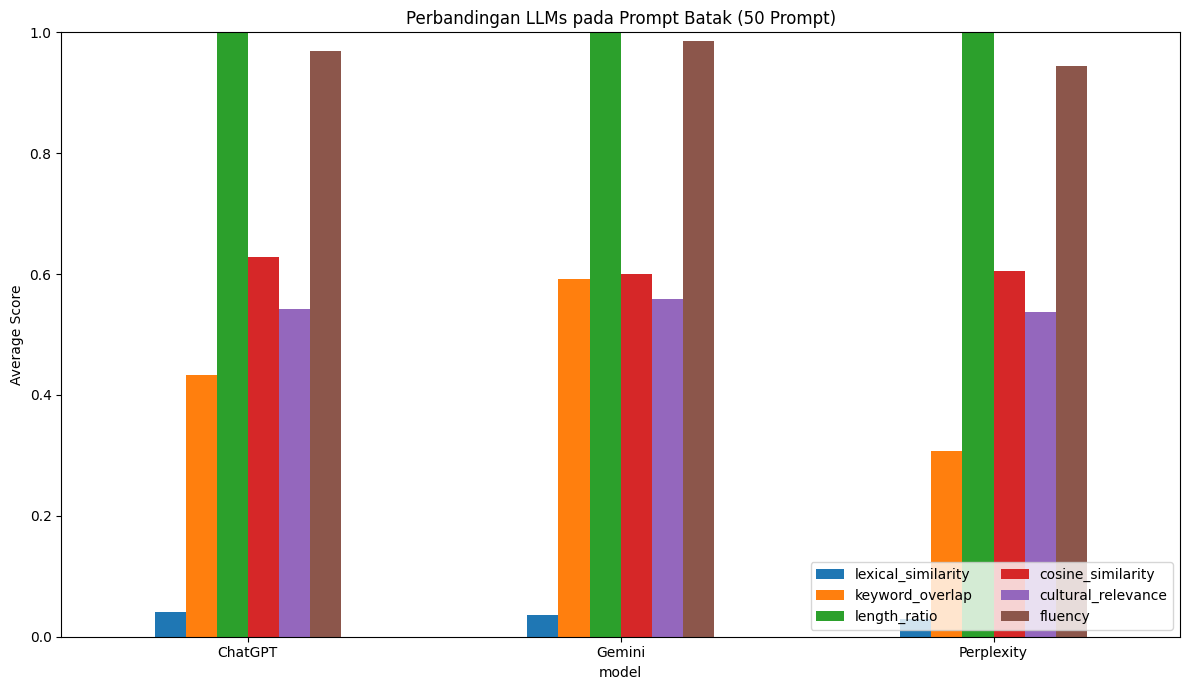

In [22]:
import matplotlib.pyplot as plt

summary_plot = summary.set_index("model")

summary_plot[[
    "lexical_similarity",
    "keyword_overlap",
    "length_ratio",
    "cosine_similarity",
    "cultural_relevance",
    "fluency"
]].plot(
    kind='bar', figsize=(12,7)
)

plt.ylabel("Average Score")
plt.title("Perbandingan LLMs pada Prompt Batak (50 Prompt)")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

In [23]:
# --- Evaluasi lengkap tiap model ---

evaluation = (
    merged.groupby("model")[
        [
            "lexical_similarity",
            "keyword_overlap",
            "length_ratio",
            "cosine_similarity",
            "cultural_relevance",
            "fluency",
        ]
    ]
    .mean()
    .reset_index()
)

print("Evaluasi Rata-rata Tiap Model")
print(evaluation)

Evaluasi Rata-rata Tiap Model
        model  lexical_similarity  keyword_overlap  length_ratio  \
0     ChatGPT            0.041251         0.432978      6.605513   
1      Gemini            0.035332         0.591384      9.882735   
2  Perplexity            0.029422         0.307379      9.712694   

   cosine_similarity  cultural_relevance   fluency  
0           0.627701            0.542105  0.968485  
1           0.599441            0.559298  0.984940  
2           0.604607            0.537895  0.944000  
